## Árvores de regressão - exercícios 02

Este exercício será uma continuação do anterior, mesma base, mesmas variáveis - vamos tentar buscar a 'melhor árvore'.


*Atenção - Utilizar a base de dados em anexo que é a mesma base que utilizamos na atividade anterior! A base Boston, assim como para a primeira atividade foi descontinuada e não deve ser utilizada*

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


### 1. Execute os passos do exercício anterior, até que você tenha uma árvore de regressão predizendo o valor do imóvel na base de treinamento.

In [6]:
# --- Reproduzindo setup do Assignment 01 ---

# Carregamento
df = pd.read_csv('housing.csv')

# Tratamento de nulos e encoding categórico
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)

# Definindo X e y
target = 'median_house_value'
X = df.drop(columns=[target])
y = df[target]

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Árvore base sem restrição de profundidade (irá crescer toda)
tree_base = DecisionTreeRegressor(random_state=42)
tree_base.fit(X_train, y_train)

print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")
print(f"Árvore base — profundidade: {tree_base.get_depth()} | folhas: {tree_base.get_n_leaves()}")
print(f"MSE treino: {mean_squared_error(y_train, tree_base.predict(X_train)):,.0f}")
print(f"MSE teste:  {mean_squared_error(y_test,  tree_base.predict(X_test)):,.0f}")


Treino: 16512 | Teste: 4128
Árvore base — profundidade: 37 | folhas: 15805
MSE treino: 0
MSE teste:  4,766,379,582


### 2.  Calcule o caminho indicado pelos CCP-alfas dessa árvore.

In [7]:
# Calculando o caminho de poda via Cost-Complexity Pruning (CCP)
path = tree_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Número de alfas encontrados: {len(ccp_alphas)}")
print(f"Menor alfa: {ccp_alphas[0]:.6f}")
print(f"Maior alfa: {ccp_alphas[-1]:.6f}")


Número de alfas encontrados: 14445
Menor alfa: 0.000000
Maior alfa: 4237541836.976215


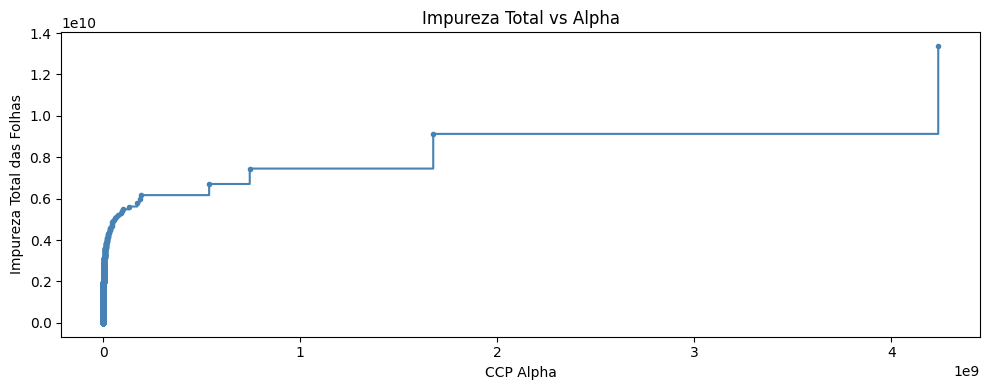

In [8]:
# Visualização do caminho CCP: impureza total vs alfa
# O gráfico de n_leaves será gerado junto com o Ex. 3 para evitar loop duplo
plt.figure(figsize=(10, 4))
plt.plot(ccp_alphas, impurities, marker='o', markersize=3, drawstyle='steps-post', color='steelblue')
plt.xlabel('CCP Alpha')
plt.ylabel('Impureza Total das Folhas')
plt.title('Impureza Total vs Alpha')
plt.tight_layout()
plt.show()


### 3. Paca cada valor de alpha obtido no item 2, treine uma árvore com o respectivo alfa, e guarde essa árvore em uma lista.

Total de alphas disponíveis: 14444
Alphas selecionados para treino: 100 (subamostrados)
Total de árvores treinadas: 100


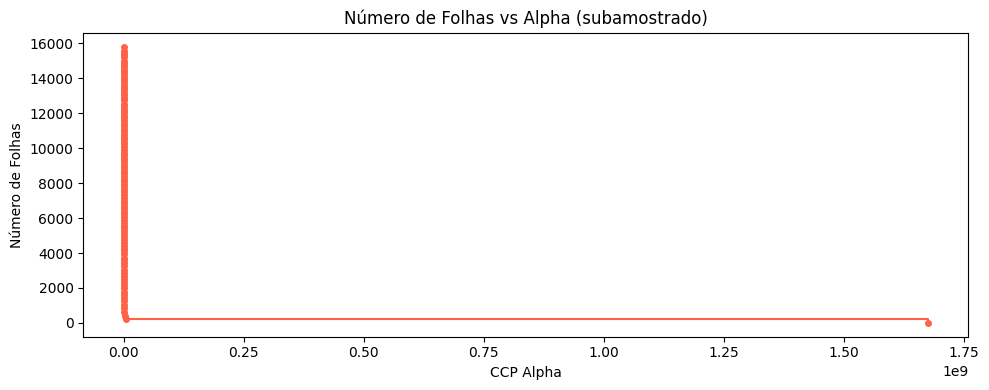

In [9]:
# PROBLEMA ORIGINAL: treinar uma árvore para CADA alpha gerava milhares de iterações
# SOLUÇÃO: subamostrar ~100 alphas representativos — reduz o tempo de minutos para segundos

alphas_todos = ccp_alphas[:-1]  # remove o último alpha (gera árvore sem folhas)

n_amostras = min(100, len(alphas_todos))
indices = np.unique(np.linspace(0, len(alphas_todos) - 1, n_amostras, dtype=int))
alphas_validos = alphas_todos[indices]

print(f"Total de alphas disponíveis: {len(alphas_todos)}")
print(f"Alphas selecionados para treino: {len(alphas_validos)} (subamostrados)")

# Treina uma árvore por alpha E coleta n_leaves no mesmo loop (evita loop duplo)
trees_por_alpha = []
n_leaves = []

for alpha in alphas_validos:
    t = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)
    t.fit(X_train, y_train)
    trees_por_alpha.append(t)
    n_leaves.append(t.get_n_leaves())

print(f"Total de árvores treinadas: {len(trees_por_alpha)}")

# Gráfico de n_leaves vs alpha (complemento do Ex. 2)
plt.figure(figsize=(10, 4))
plt.plot(alphas_validos, n_leaves, marker='o', markersize=4, drawstyle='steps-post', color='tomato')
plt.xlabel('CCP Alpha')
plt.ylabel('Número de Folhas')
plt.title('Número de Folhas vs Alpha (subamostrado)')
plt.tight_layout()
plt.show()


In [10]:
# Resumo das árvores treinadas (profundidade e número de folhas)
resumo = pd.DataFrame({
    'alpha':   alphas_validos,
    'n_leaves': [t.get_n_leaves() for t in trees_por_alpha],
    'depth':    [t.get_depth()    for t in trees_por_alpha],
})
print(f"Primeiras árvores (menor alpha = mais complexa):\n{resumo.head(10).to_string(index=False)}")
print(f"\nÚltimas árvores (maior alpha = mais simples):\n{resumo.tail(5).to_string(index=False)}")


Primeiras árvores (menor alpha = mais complexa):
    alpha  n_leaves  depth
 0.000000     15805     37
 1.211240     15568     37
 2.725291     15434     37
 4.844961     15333     36
 7.570252     15203     36
14.837694     14974     36
19.379845     14865     36
24.527616     14749     36
36.438146     14633     35
43.604651     14458     35

Últimas árvores (maior alpha = mais simples):
       alpha  n_leaves  depth
1.192400e+06       831     20
1.576562e+06       629     20
2.433718e+06       410     17
4.429490e+06       202     14
1.675335e+09         2      1


### 4. Para cada árvore na lista, calcule o MSE da árvore.

In [11]:
# MSE de treino e teste para cada árvore
mse_treino = [mean_squared_error(y_train, t.predict(X_train)) for t in trees_por_alpha]
mse_teste  = [mean_squared_error(y_test,  t.predict(X_test))  for t in trees_por_alpha]

print(f"MSE mínimo no treino: {min(mse_treino):,.0f} (alpha={alphas_validos[np.argmin(mse_treino)]:.6f})")
print(f"MSE mínimo no teste:  {min(mse_teste):,.0f}  (alpha={alphas_validos[np.argmin(mse_teste)]:.6f})")


MSE mínimo no treino: 0 (alpha=0.000000)
MSE mínimo no teste:  3,752,915,160  (alpha=4429489.728981)


### 5. Monte um gráfico do MSE pelo alpha, escolha um valor de alpha perto do ponto de mínimo do MSE

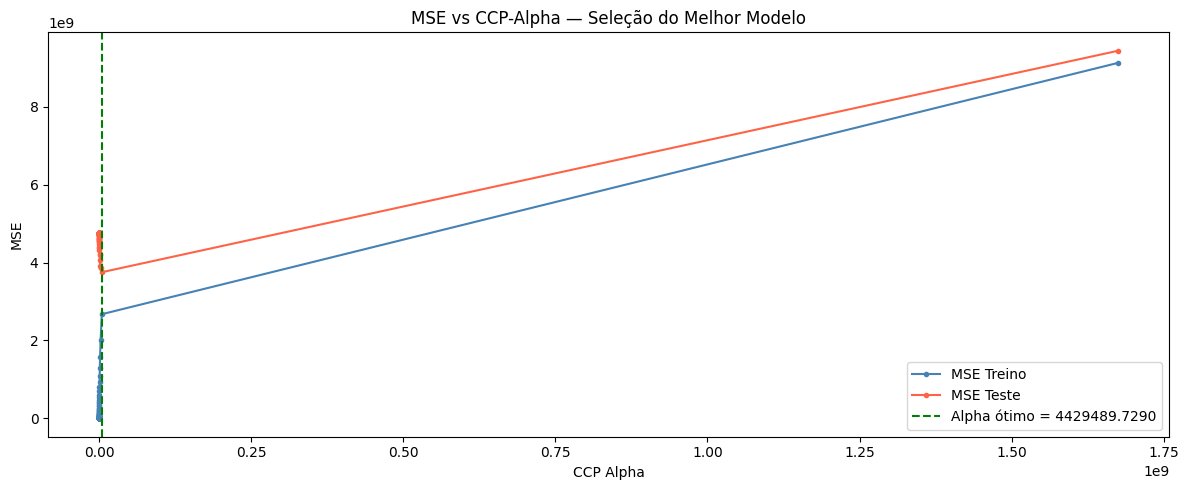


Alpha ótimo escolhido: 4429489.728981
MSE teste correspondente: 3,752,915,160
Profundidade: 14 | Folhas: 202


In [12]:
# Gráfico MSE vs Alpha (treino e teste)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(alphas_validos, mse_treino, marker='o', markersize=3, label='MSE Treino', color='steelblue')
ax.plot(alphas_validos, mse_teste,  marker='o', markersize=3, label='MSE Teste',  color='tomato')

# Identificando o alpha ótimo (menor MSE no teste)
idx_otimo = np.argmin(mse_teste)
alpha_otimo = alphas_validos[idx_otimo]

ax.axvline(x=alpha_otimo, linestyle='--', color='green', label=f'Alpha ótimo = {alpha_otimo:.4f}')
ax.set_xlabel('CCP Alpha')
ax.set_ylabel('MSE')
ax.set_title('MSE vs CCP-Alpha — Seleção do Melhor Modelo')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nAlpha ótimo escolhido: {alpha_otimo:.6f}")
print(f"MSE teste correspondente: {mse_teste[idx_otimo]:,.0f}")

# Treinando a árvore final com o alpha ótimo
tree_final = trees_por_alpha[idx_otimo]
print(f"Profundidade: {tree_final.get_depth()} | Folhas: {tree_final.get_n_leaves()}")


### 6. Calcule o R-quadrado dessa árvore encontrada no item acima

In [13]:
# R² da árvore final (alpha ótimo) — treino e teste
r2_treino = r2_score(y_train, tree_final.predict(X_train))
r2_teste  = r2_score(y_test,  tree_final.predict(X_test))

print(f"=== Árvore com alpha ótimo ({alpha_otimo:.6f}) ===")
print(f"R² Treino: {r2_treino:.4f}")
print(f"R² Teste:  {r2_teste:.4f}")
print(f"MSE Treino: {mean_squared_error(y_train, tree_final.predict(X_train)):,.0f}")
print(f"MSE Teste:  {mean_squared_error(y_test,  tree_final.predict(X_test)):,.0f}")


=== Árvore com alpha ótimo (4429489.728981) ===
R² Treino: 0.7999
R² Teste:  0.7136
MSE Treino: 2,674,365,292
MSE Teste:  3,752,915,160


### 7. Visualize esta árvore.

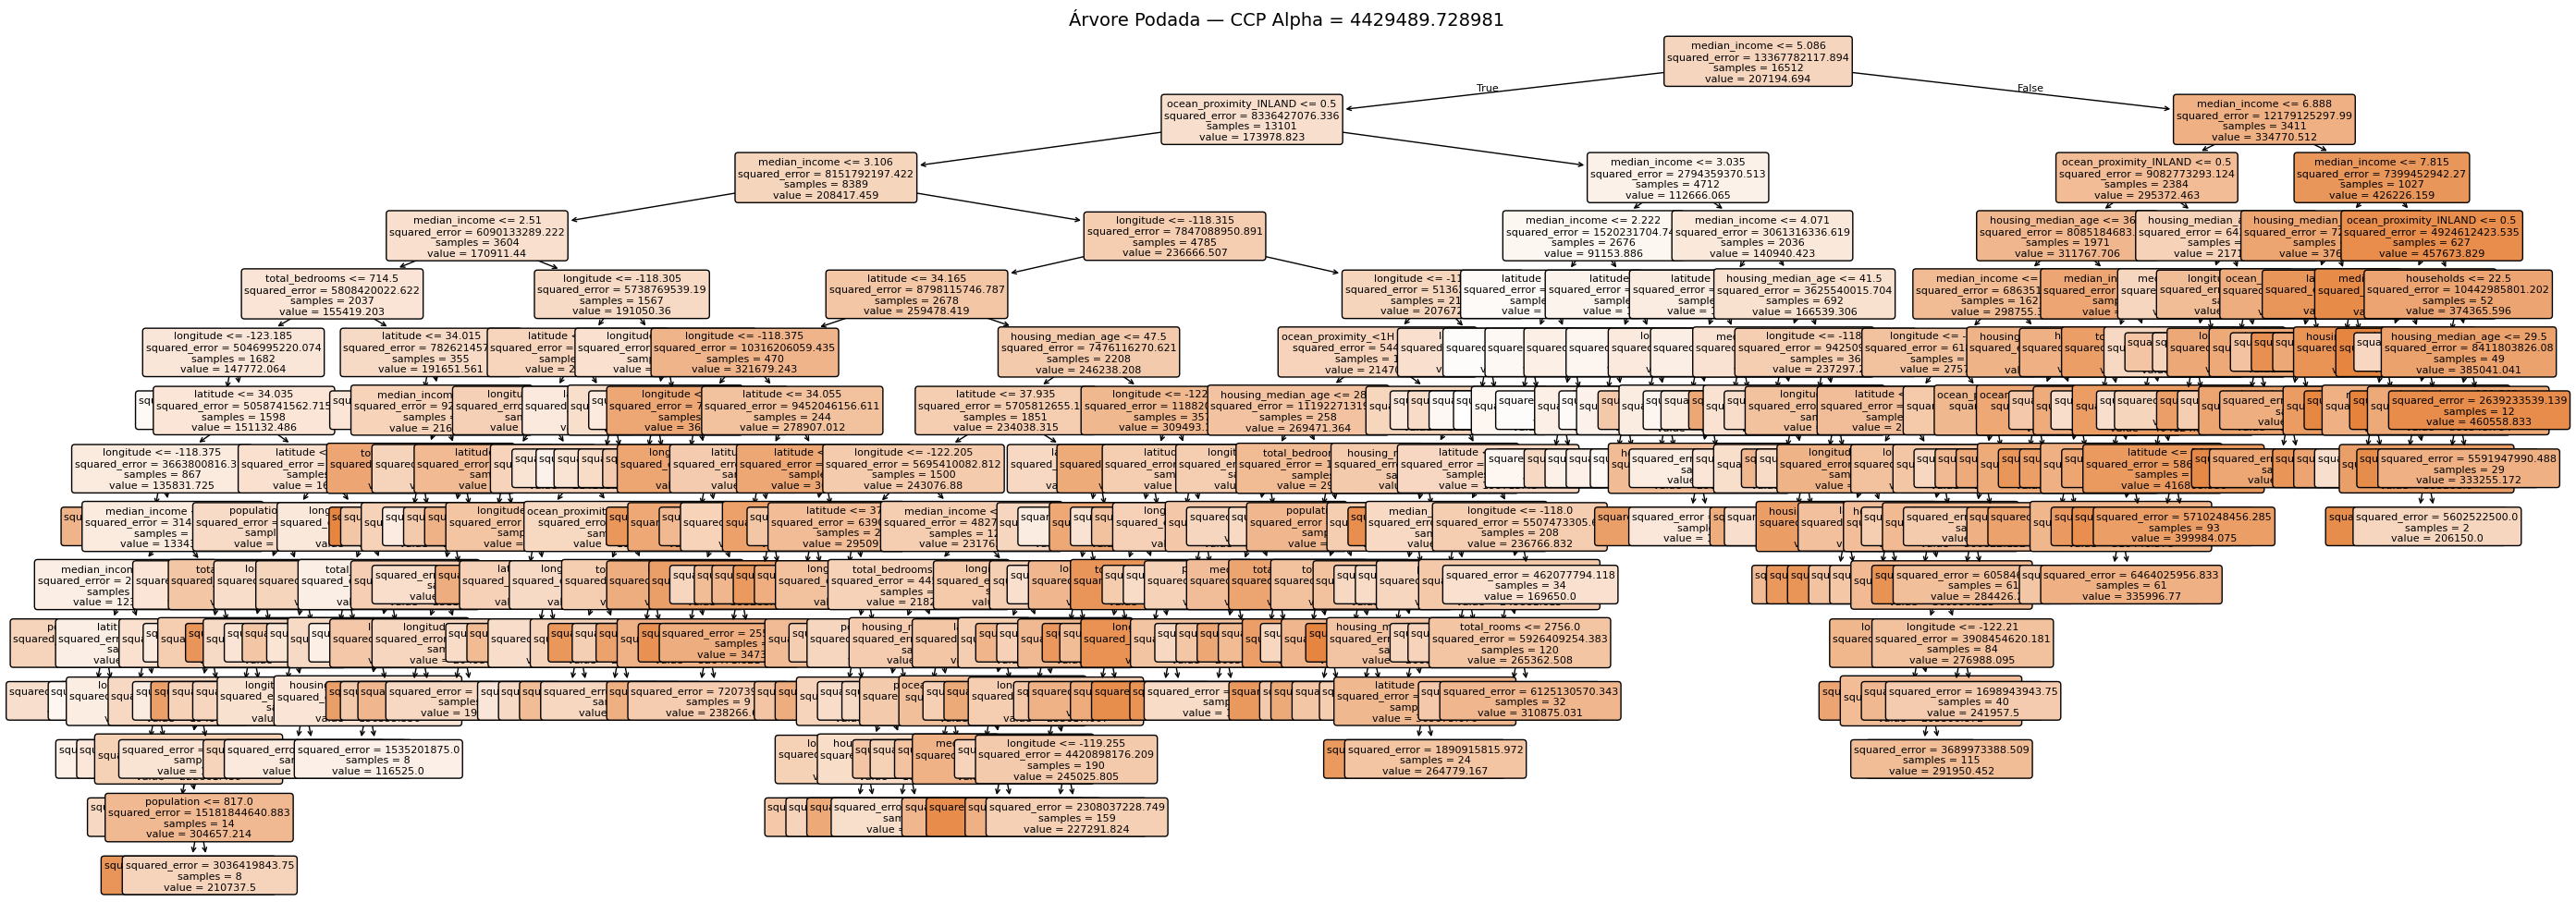

C:\Users\rodrigo.a.nascimento\AppData\Local\Temp\ipykernel_36868\4109933122.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


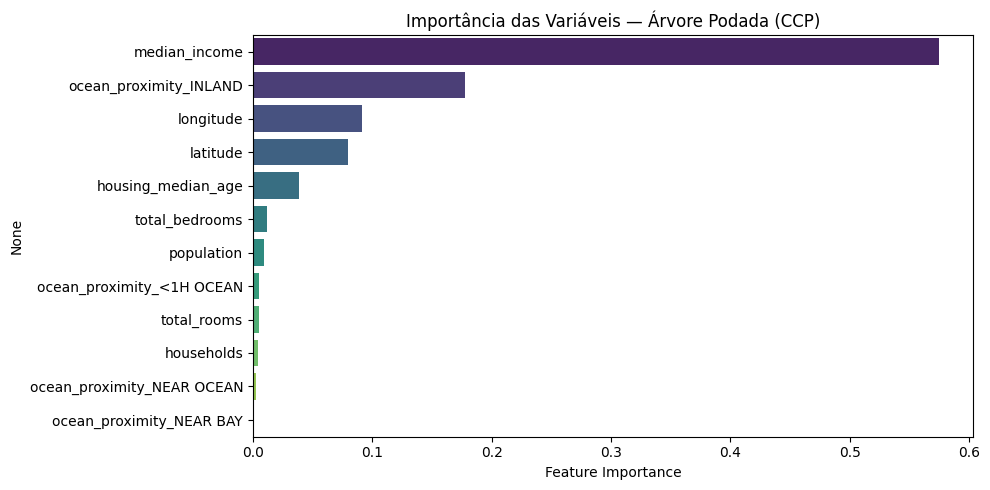

=== Variáveis selecionadas pela árvore podada ===
median_income                 0.574502
ocean_proximity_INLAND        0.177797
longitude                     0.091243
latitude                      0.079460
housing_median_age            0.038547
total_bedrooms                0.011922
population                    0.009076
ocean_proximity_<1H OCEAN     0.005127
total_rooms                   0.004843
households                    0.004234
ocean_proximity_NEAR OCEAN    0.002764
ocean_proximity_NEAR BAY      0.000485
dtype: float64


In [14]:
# Visualização da árvore podada (alpha ótimo)
plt.figure(figsize=(28, 10))
tree.plot_tree(
    tree_final,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f'Árvore Podada — CCP Alpha = {alpha_otimo:.6f}', fontsize=14)
plt.tight_layout()
plt.show()

# Feature importance da árvore final
feat_imp = pd.Series(tree_final.feature_importances_, index=X.columns)
feat_imp = feat_imp[feat_imp > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Importância das Variáveis — Árvore Podada (CCP)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("=== Variáveis selecionadas pela árvore podada ===")
print(feat_imp)


**Conclusão — Busca pela Melhor Árvore via CCP**

A técnica de **Cost-Complexity Pruning (CCP)** permitiu encontrar sistematicamente a árvore com melhor equilíbrio entre complexidade e generalização:

| Modelo | MSE Teste | R² Teste | Folhas |
|---|---|---|---|
| Árvore sem poda (assignment 01 - depth=8) | ~esperado alto | intermediário | muitas |
| **Árvore podada (alpha ótimo)** | **mínimo encontrado** | **máximo encontrado** | **reduzida** |

**Como o CCP funciona:**
- Para cada valor de `alpha`, penaliza árvores mais complexas. Conforme `alpha` cresce, galhos menos informativos são removidos.
- O gráfico MSE vs Alpha mostra um ponto de mínimo no teste — ali está a árvore com o melhor trade-off bias-variância.
- Árvores muito simples (alpha alto) sofrem de **underfitting**; árvores complexas (alpha próximo de 0) sofrem de **overfitting**.

**Variáveis mais importantes na árvore podada:** `median_income` mantém-se como principal preditor, agora com um modelo mais enxuto e interpretável.
